In [4]:
from pathlib import Path
import pandas as pd
import seaborn as sns
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import random
import numpy as np
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# IMPORTS PARA PIPELINE DE TENSORES (TORCH)
# ==========================================
# Se usan para:
# - Transformar imágenes a tensores con batching
# - Evitar cargar imagen por imagen en Python (más lento)
# - Mantener un flujo tipo notebook 1 (Dataset -> DataLoader -> batches)

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

### Pre EDA

===== CLASS DISTRIBUTION =====
  class  count  percentage
0    ai   3241    7.764548
1  real  38500   92.235452

Total images: 41741
Class ratio (Real/AI): 11.88


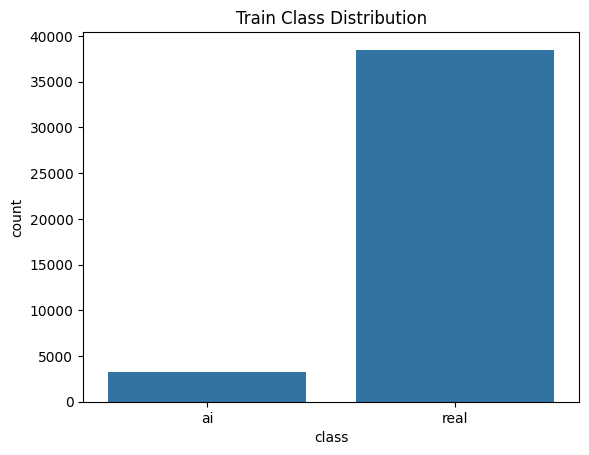

In [5]:
PROJECT_ROOT = Path().resolve().parent

TRAIN_PATH = PROJECT_ROOT / "data" / "interim" / "train"

counts = []

for cls in ["ai", "real"]:
    n = len(list((TRAIN_PATH / cls).glob("*")))
    counts.append({"class": cls, "count": n})

df_counts = pd.DataFrame(counts)

# Estadísticas numéricas
total_images = df_counts["count"].sum()
df_counts["percentage"] = df_counts["count"] / total_images * 100

print("===== CLASS DISTRIBUTION =====")
print(df_counts)
print(f"\nTotal images: {total_images}")
print(f"Class ratio (Real/AI): {df_counts.iloc[1]['count'] / df_counts.iloc[0]['count']:.2f}")

# Gráfico
sns.barplot(data=df_counts, x="class", y="count")
plt.title("Train Class Distribution")
plt.show()

===== IMAGE SIZE STATS =====
       width                height               
        mean  std  min  max   mean  std  min  max
class                                            
ai     256.0  0.0  256  256  256.0  0.0  256  256
real   178.0  0.0  178  178  218.0  0.0  218  218


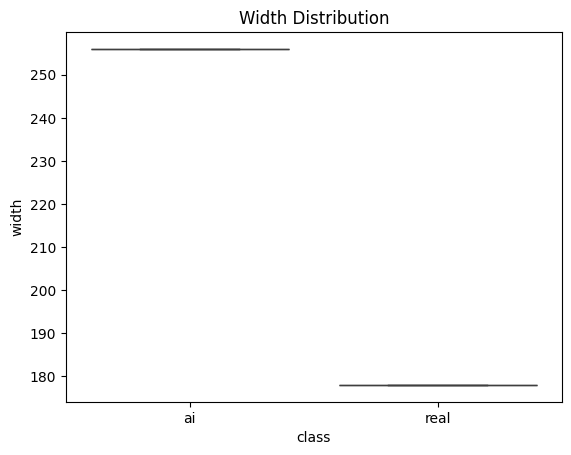

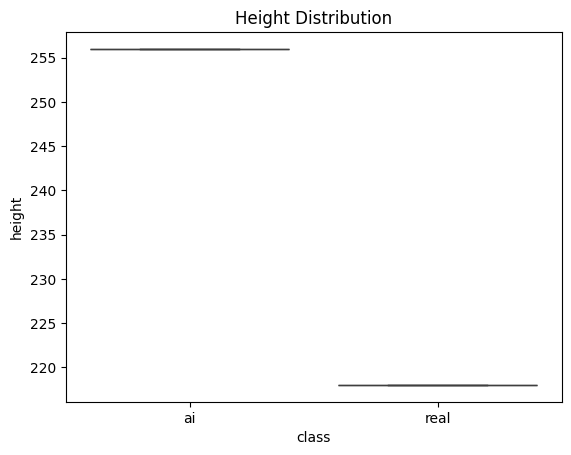

In [6]:


sizes = []

for cls in ["ai", "real"]:
    for img_path in list((TRAIN_PATH / cls).glob("*"))[:1000]:
        with Image.open(img_path) as img:
            sizes.append({
                "class": cls,
                "width": img.width,
                "height": img.height
            })

df_sizes = pd.DataFrame(sizes)

print("===== IMAGE SIZE STATS =====")
print(df_sizes.groupby("class").agg(["mean","std","min","max"]))

plt.figure()
sns.boxplot(data=df_sizes, x="class", y="width")
plt.title("Width Distribution")
plt.show()

plt.figure()
sns.boxplot(data=df_sizes, x="class", y="height")
plt.title("Height Distribution")
plt.show()

===== BRIGHTNESS STATS =====
        count      mean       std       min       25%       50%       75%  \
class                                                                       
ai     1000.0  0.539765  0.070199  0.315911  0.495574  0.544370  0.588363   
real   1000.0  0.440856  0.146687  0.100337  0.326753  0.436275  0.547564   

            max  
class            
ai     0.718075  
real   0.878551  


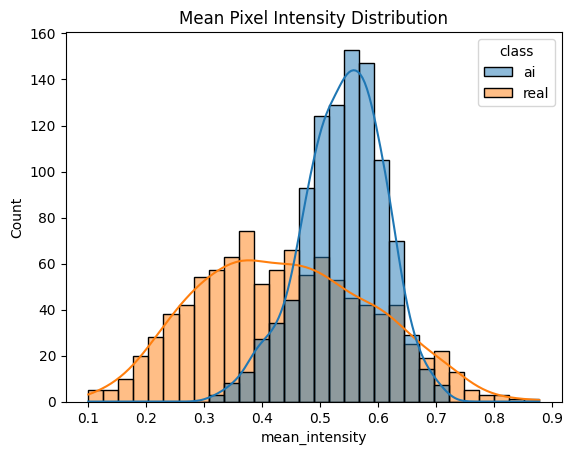

In [7]:
brightness = []

for cls in ["ai", "real"]:
    for img_path in list((TRAIN_PATH / cls).glob("*"))[:1000]:
        with Image.open(img_path) as img:
            img = np.array(img) / 255.0
            brightness.append({
                "class": cls,
                "mean_intensity": img.mean()
            })

df_brightness = pd.DataFrame(brightness)

print("===== BRIGHTNESS STATS =====")
print(df_brightness.groupby("class")["mean_intensity"].describe())

sns.histplot(data=df_brightness, x="mean_intensity", hue="class", kde=True)
plt.title("Mean Pixel Intensity Distribution")
plt.show()

===== VARIANCE STATS =====
        count      mean       std       min       25%       50%       75%  \
class                                                                       
ai     1000.0  0.059673  0.016592  0.015949  0.047509  0.060254  0.071976   
real   1000.0  0.071233  0.025860  0.011770  0.052195  0.068261  0.086870   

            max  
class            
ai     0.104605  
real   0.165856  


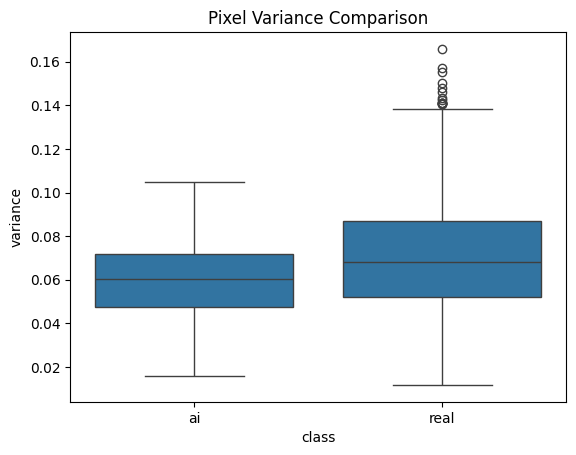

In [8]:
variance = []

for cls in ["ai", "real"]:
    for img_path in list((TRAIN_PATH / cls).glob("*"))[:1000]:
        with Image.open(img_path) as img:
            img = np.array(img) / 255.0
            variance.append({
                "class": cls,
                "variance": img.var()
            })

df_var = pd.DataFrame(variance)

print("===== VARIANCE STATS =====")
print(df_var.groupby("class")["variance"].describe())

sns.boxplot(data=df_var, x="class", y="variance")
plt.title("Pixel Variance Comparison")
plt.show()

===== RGB CHANNEL STATS =====
        r_mean              g_mean              b_mean          
          mean       std      mean       std      mean       std
class                                                           
ai     0.61373  0.072211  0.523272  0.074939  0.475696  0.080001
real   0.51135  0.153948  0.431657  0.148035  0.390449  0.150977


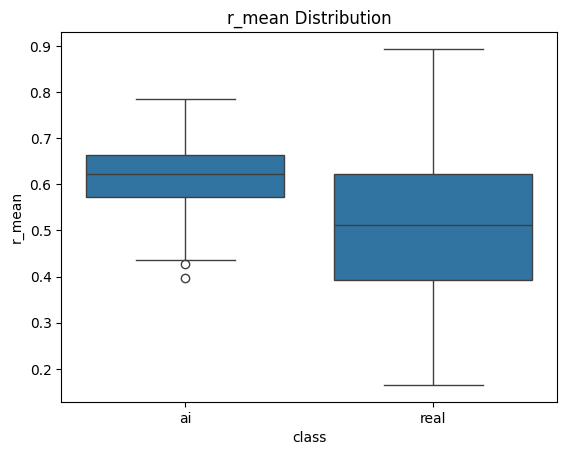

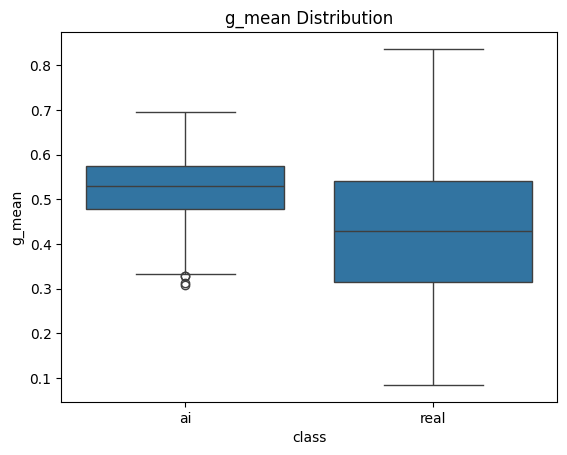

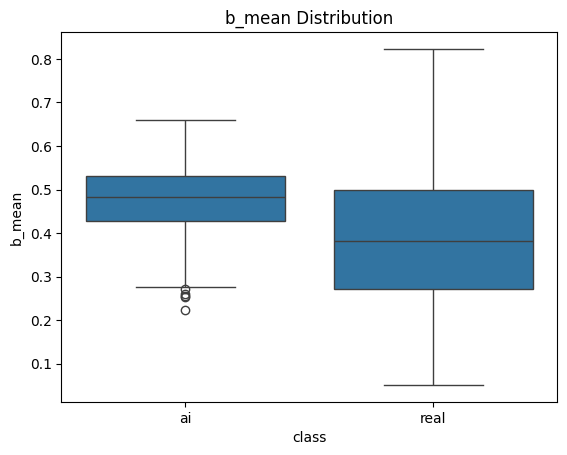

In [9]:
rgb_stats = []

for cls in ["ai", "real"]:
    for img_path in list((TRAIN_PATH / cls).glob("*"))[:500]:
        with Image.open(img_path) as img:
            img = np.array(img) / 255.0
            
            rgb_stats.append({
                "class": cls,
                "r_mean": img[:,:,0].mean(),
                "g_mean": img[:,:,1].mean(),
                "b_mean": img[:,:,2].mean()
            })

df_rgb = pd.DataFrame(rgb_stats)

print("===== RGB CHANNEL STATS =====")
print(df_rgb.groupby("class").agg(["mean","std"]))

for channel in ["r_mean","g_mean","b_mean"]:
    sns.boxplot(data=df_rgb, x="class", y=channel)
    plt.title(f"{channel} Distribution")
    plt.show()

In [10]:


ai_vals = df_brightness[df_brightness["class"]=="ai"]["mean_intensity"]
real_vals = df_brightness[df_brightness["class"]=="real"]["mean_intensity"]

t_stat, p_val = ttest_ind(ai_vals, real_vals)

print("===== T-TEST BRIGHTNESS =====")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.6f}")

===== T-TEST BRIGHTNESS =====
T-statistic: 19.2337
P-value: 0.000000


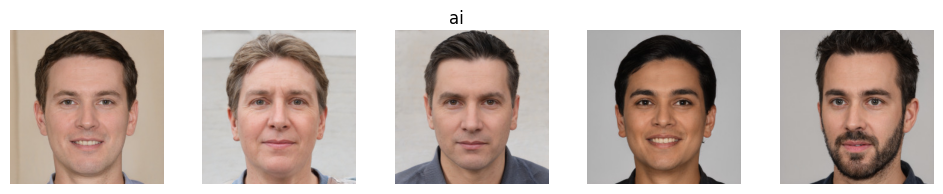

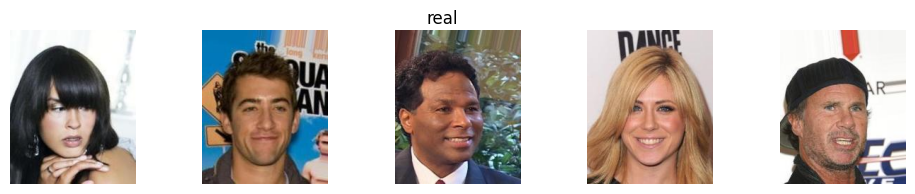

In [11]:

def show_samples(cls):
    imgs = list((TRAIN_PATH / cls).glob("*"))
    samples = random.sample(imgs, 5)
    
    plt.figure(figsize=(12,2))
    for i, img_path in enumerate(samples):
        plt.subplot(1,5,i+1)
        plt.imshow(Image.open(img_path))
        plt.axis("off")
    plt.suptitle(cls)
    plt.show()

show_samples("ai")
show_samples("real")

### Solving DeBalance

In [12]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import random
import random
import shutil
import matplotlib.pyplot as plt
import random
from pathlib import Path
from PIL import Image
import os
from pathlib import Path
import seaborn as sns
from PIL import Image
import numpy as np
from pathlib import Path

===== SPLIT DISTRIBUTION =====
class    ai   real  ratio_real_ai
split                            
test    695   8250      11.870504
train  3241  38500      11.879050
val     694   8250      11.887608


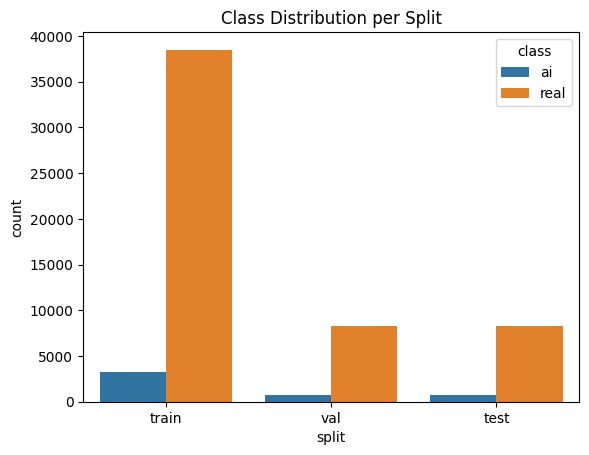

In [13]:

INTERIM_PATH = PROJECT_ROOT / "data" / "interim"

results = []

for split in ["train", "val", "test"]:
    for cls in ["ai", "real"]:
        n = len(list((INTERIM_PATH / split / cls).glob("*")))
        results.append({
            "split": split,
            "class": cls,
            "count": n
        })

df_split = pd.DataFrame(results)

df_pivot = df_split.pivot(index="split", columns="class", values="count")
df_pivot["ratio_real_ai"] = df_pivot["real"] / df_pivot["ai"]

print("===== SPLIT DISTRIBUTION =====")
print(df_pivot)

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df_split, x="split", y="count", hue="class")
plt.title("Class Distribution per Split")
plt.show()

===== REAL SOURCE DISTRIBUTION =====
Kaggle Real: 5000
CelebA Real: 50000
Total Real: 55000
CelebA %: 90.91%


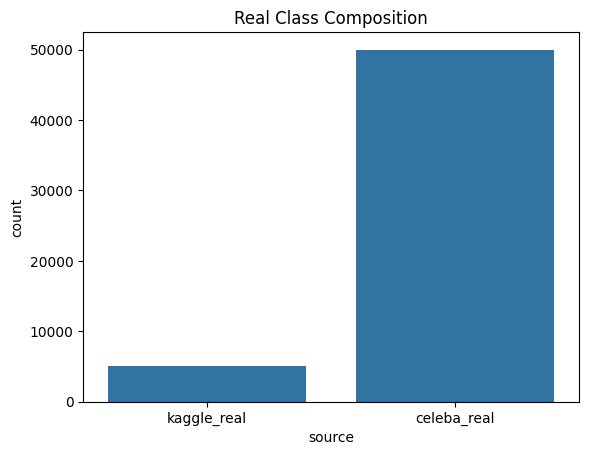

In [14]:
RAW_PATH = PROJECT_ROOT / "data" / "raw"

real_kaggle = len(list((RAW_PATH / "real").glob("*")))
celeba_real = len(list((RAW_PATH / "celeba_real").glob("*")))

print("===== REAL SOURCE DISTRIBUTION =====")
print(f"Kaggle Real: {real_kaggle}")
print(f"CelebA Real: {celeba_real}")
print(f"Total Real: {real_kaggle + celeba_real}")
print(f"CelebA %: {celeba_real / (real_kaggle + celeba_real) * 100:.2f}%")

df_real_sources = pd.DataFrame({
    "source": ["kaggle_real", "celeba_real"],
    "count": [real_kaggle, celeba_real]
})

sns.barplot(data=df_real_sources, x="source", y="count")
plt.title("Real Class Composition")
plt.show()

        count      mean       std       min       25%       50%       75%  \
source                                                                      
celeba  500.0  0.443178  0.146131  0.112426  0.328256  0.436861  0.553246   
kaggle  500.0  0.448477  0.139416  0.151490  0.340665  0.442694  0.559254   

             max  
source            
celeba  0.813974  
kaggle  0.805280  


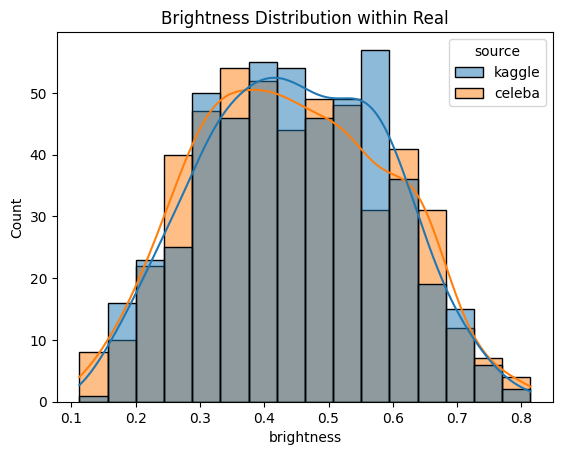

In [15]:


def sample_brightness(folder, n=500):
    paths = list(folder.glob("*"))
    samples = random.sample(paths, min(n, len(paths)))
    values = []
    for p in samples:
        with Image.open(p) as img:
            img = np.array(img) / 255.0
            values.append(img.mean())
    return values

kaggle_brightness = sample_brightness(RAW_PATH / "real")
celeba_brightness = sample_brightness(RAW_PATH / "celeba_real")

df_real_internal = pd.DataFrame({
    "brightness": kaggle_brightness + celeba_brightness,
    "source": ["kaggle"] * len(kaggle_brightness) + ["celeba"] * len(celeba_brightness)
})

print(df_real_internal.groupby("source")["brightness"].describe())

sns.histplot(data=df_real_internal, x="brightness", hue="source", kde=True)
plt.title("Brightness Distribution within Real")
plt.show()

In [16]:
ai_count = df_pivot.loc["train", "ai"]
real_count = df_pivot.loc["train", "real"]

print("If subsampled:")
print(f"New dataset size: {ai_count * 2}")

If subsampled:
New dataset size: 6482


In [17]:
print("If not subsampled:")
print(f"Dataset size: {ai_count + real_count}")

If not subsampled:
Dataset size: 41741


In [18]:
random.seed(42)

INTERIM_PATH = PROJECT_ROOT / "data" / "interim"

splits = ["train", "val", "test"]

for split in splits:
    
    original_split_path = INTERIM_PATH / split
    balanced_split_path = INTERIM_PATH / f"{split}_balanced"
    
    # Crear carpetas destino
    for cls in ["ai", "real"]:
        (balanced_split_path / cls).mkdir(parents=True, exist_ok=True)
    
    # Listar imágenes
    ai_images = list((original_split_path / "ai").glob("*"))
    real_images = list((original_split_path / "real").glob("*"))
    
    ai_count = len(ai_images)
    real_count = len(real_images)
    
    print(f"\n===== {split.upper()} =====")
    print(f"Original → AI: {ai_count}, REAL: {real_count}")
    
    # Subsample real
    real_sampled = random.sample(real_images, ai_count)
    
    # Copiar AI completas
    for img_path in ai_images:
        shutil.copy(img_path, balanced_split_path / "ai" / img_path.name)
    
    # Copiar REAL subsampleadas
    for img_path in real_sampled:
        shutil.copy(img_path, balanced_split_path / "real" / img_path.name)
    
    print(f"Balanced → AI: {ai_count}, REAL: {ai_count}")


===== TRAIN =====
Original → AI: 3241, REAL: 38500
Balanced → AI: 3241, REAL: 3241

===== VAL =====
Original → AI: 694, REAL: 8250
Balanced → AI: 694, REAL: 694

===== TEST =====
Original → AI: 695, REAL: 8250
Balanced → AI: 695, REAL: 695


In [19]:
for split in splits:
    ai_n = len(list((INTERIM_PATH / f"{split}_balanced" / "ai").glob("*")))
    real_n = len(list((INTERIM_PATH / f"{split}_balanced" / "real").glob("*")))
    print(f"{split}_balanced → AI: {ai_n}, REAL: {real_n}")

train_balanced → AI: 3241, REAL: 3241
val_balanced → AI: 694, REAL: 694
test_balanced → AI: 695, REAL: 695


### Solving Resolution

In [20]:
TRAIN_BAL = PROJECT_ROOT / "data" / "interim" / "train_balanced"

sizes = []

for cls in ["ai", "real"]:
    for img_path in (TRAIN_BAL / cls).glob("*"):
        with Image.open(img_path) as img:
            sizes.append({
                "class": cls,
                "width": img.width,
                "height": img.height,
                "aspect_ratio": img.width / img.height
            })

df_sizes_bal = pd.DataFrame(sizes)

print("===== SIZE STATS (TRAIN_BALANCED) =====")
print(df_sizes_bal.groupby("class").agg(["mean","std","min","max"]))

===== SIZE STATS (TRAIN_BALANCED) =====
       width                height                aspect_ratio                 \
        mean  std  min  max   mean  std  min  max         mean  std       min   
class                                                                           
ai     256.0  0.0  256  256  256.0  0.0  256  256     1.000000  0.0  1.000000   
real   178.0  0.0  178  178  218.0  0.0  218  218     0.816514  0.0  0.816514   

                 
            max  
class            
ai     1.000000  
real   0.816514  


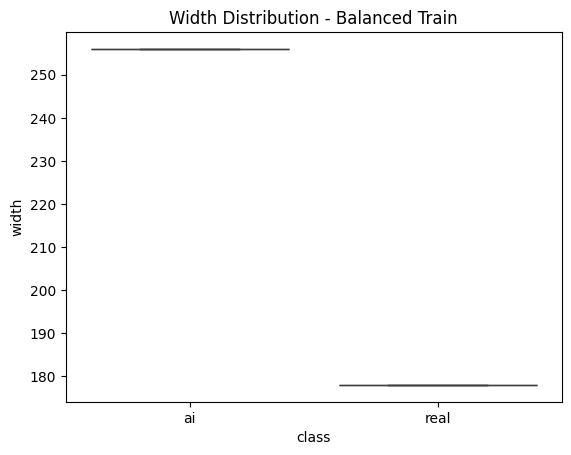

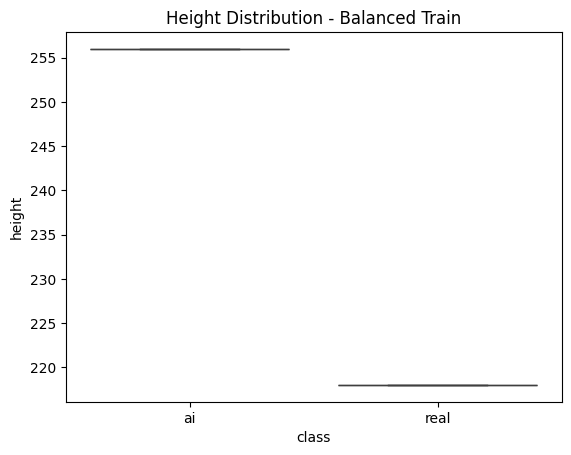

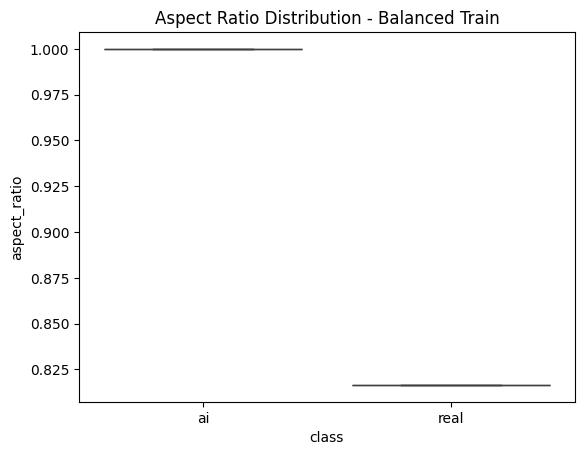

In [21]:


plt.figure()
sns.boxplot(data=df_sizes_bal, x="class", y="width")
plt.title("Width Distribution - Balanced Train")
plt.show()

plt.figure()
sns.boxplot(data=df_sizes_bal, x="class", y="height")
plt.title("Height Distribution - Balanced Train")
plt.show()

plt.figure()
sns.boxplot(data=df_sizes_bal, x="class", y="aspect_ratio")
plt.title("Aspect Ratio Distribution - Balanced Train")
plt.show()

In [22]:
def resolution_summary(split_name):
    split_path = PROJECT_ROOT / "data" / "interim" / f"{split_name}_balanced"
    data = []
    
    for cls in ["ai", "real"]:
        for img_path in (split_path / cls).glob("*"):
            with Image.open(img_path) as img:
                data.append({
                    "class": cls,
                    "width": img.width,
                    "height": img.height
                })
    
    df = pd.DataFrame(data)
    print(f"\n===== {split_name.upper()} BALANCED =====")
    print(df.groupby("class").agg(["mean","std"]))

resolution_summary("val")
resolution_summary("test")


===== VAL BALANCED =====
       width      height     
        mean  std   mean  std
class                        
ai     256.0  0.0  256.0  0.0
real   178.0  0.0  218.0  0.0

===== TEST BALANCED =====
       width      height     
        mean  std   mean  std
class                        
ai     256.0  0.0  256.0  0.0
real   178.0  0.0  218.0  0.0


In [23]:


TARGET_SIZE = 128
INTERIM_PATH = PROJECT_ROOT / "data" / "interim"
splits = ["train", "val", "test"]

def center_crop_square(img):
    width, height = img.size
    min_side = min(width, height)
    
    left = (width - min_side) // 2
    top = (height - min_side) // 2
    right = left + min_side
    bottom = top + min_side
    
    return img.crop((left, top, right, bottom))

for split in splits:
    
    source_path = INTERIM_PATH / f"{split}_balanced"
    dest_path = INTERIM_PATH / f"{split}_balanced_resized"
    
    for cls in ["ai", "real"]:
        (dest_path / cls).mkdir(parents=True, exist_ok=True)
        
        for img_path in (source_path / cls).glob("*"):
            
            with Image.open(img_path) as img:
                img = img.convert("RGB")
                
                
                img = center_crop_square(img)
                
                
                img = img.resize((TARGET_SIZE, TARGET_SIZE), Image.LANCZOS)
                
                
                img.save(dest_path / cls / img_path.name)

print("Resize + crop completado correctamente")

Resize + crop completado correctamente


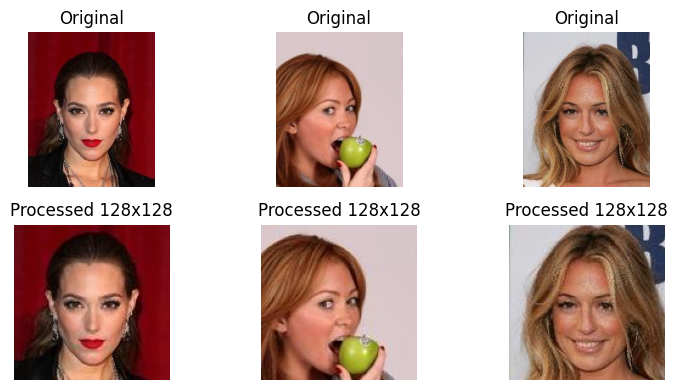

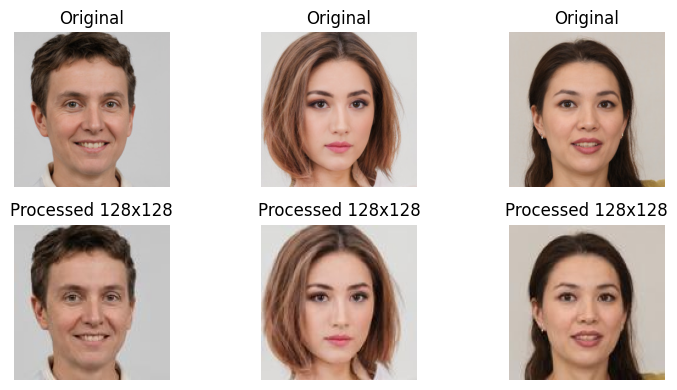

In [24]:


def show_comparison(split="train", cls="real"):
    
    original_path = INTERIM_PATH / f"{split}_balanced" / cls
    resized_path = INTERIM_PATH / f"{split}_balanced_resized" / cls
    
    samples = random.sample(list(original_path.glob("*")), 3)
    
    plt.figure(figsize=(8,4))
    
    for i, img_path in enumerate(samples):
        
        original_img = Image.open(img_path)
        resized_img = Image.open(resized_path / img_path.name)
        
        # Original
        plt.subplot(2,3,i+1)
        plt.imshow(original_img)
        plt.title("Original")
        plt.axis("off")
        
        # Resized
        plt.subplot(2,3,i+4)
        plt.imshow(resized_img)
        plt.title("Processed 128x128")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_comparison("train", "real")
show_comparison("train", "ai")

### Solving Brightness

===== BRIGHTNESS STATS (RESIZED) =====
        count      mean       std       min       25%       50%       75%  \
class                                                                       
ai     3241.0  0.537930  0.071125  0.259387  0.493340  0.544485  0.589380   
real   3241.0  0.439686  0.140718  0.097227  0.331952  0.433820  0.541321   

            max  
class            
ai     0.729178  
real   0.852983  


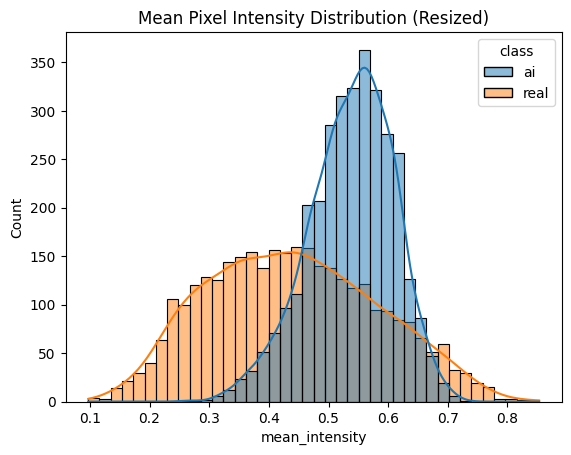

In [25]:


TRAIN_RESIZED = PROJECT_ROOT / "data" / "interim" / "train_balanced_resized"

brightness = []

for cls in ["ai", "real"]:
    for img_path in (TRAIN_RESIZED / cls).glob("*"):
        with Image.open(img_path) as img:
            img = np.array(img) / 255.0
            brightness.append({
                "class": cls,
                "mean_intensity": img.mean()
            })

df_brightness_resized = pd.DataFrame(brightness)

print("===== BRIGHTNESS STATS (RESIZED) =====")
print(df_brightness_resized.groupby("class")["mean_intensity"].describe())

sns.histplot(data=df_brightness_resized,
             x="mean_intensity",
             hue="class",
             kde=True,
             bins=40)

plt.title("Mean Pixel Intensity Distribution (Resized)")
plt.show()

In [26]:
mean_ai = df_brightness_resized[df_brightness_resized["class"]=="ai"]["mean_intensity"].mean()
mean_real = df_brightness_resized[df_brightness_resized["class"]=="real"]["mean_intensity"].mean()

diff = abs(mean_ai - mean_real)

print("===== MEAN DIFFERENCE =====")
print(f"AI mean:   {mean_ai:.4f}")
print(f"Real mean: {mean_real:.4f}")
print(f"Absolute difference: {diff:.4f}")

===== MEAN DIFFERENCE =====
AI mean:   0.5379
Real mean: 0.4397
Absolute difference: 0.0982


In [27]:


ai_vals = df_brightness_resized[df_brightness_resized["class"]=="ai"]["mean_intensity"]
real_vals = df_brightness_resized[df_brightness_resized["class"]=="real"]["mean_intensity"]

t_stat, p_val = ttest_ind(ai_vals, real_vals)

print("===== T-TEST RESULT =====")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.8f}")

===== T-TEST RESULT =====
T-statistic: 35.4723
P-value: 0.00000000


===== RGB CHANNEL STATS (RESIZED) =====
         r_mean              g_mean             b_mean          
           mean       std      mean       std     mean       std
class                                                           
ai     0.612835  0.068539  0.523823  0.071469  0.47713  0.076380
real   0.512731  0.149899  0.425848  0.143360  0.38048  0.144793


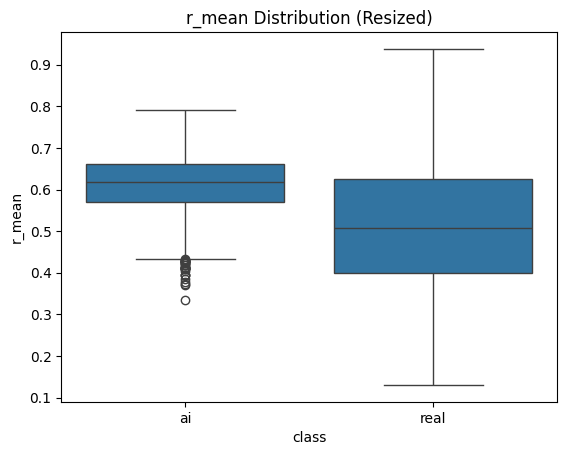

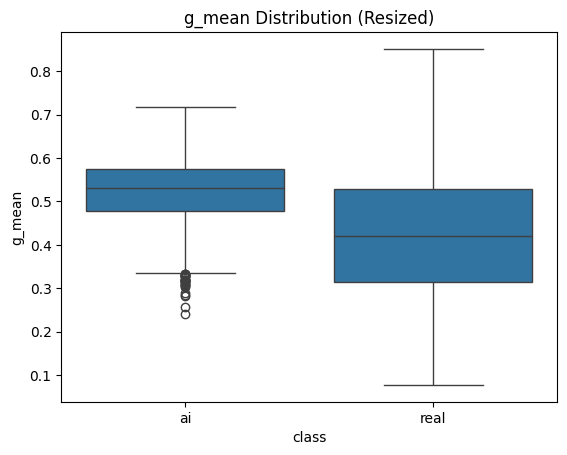

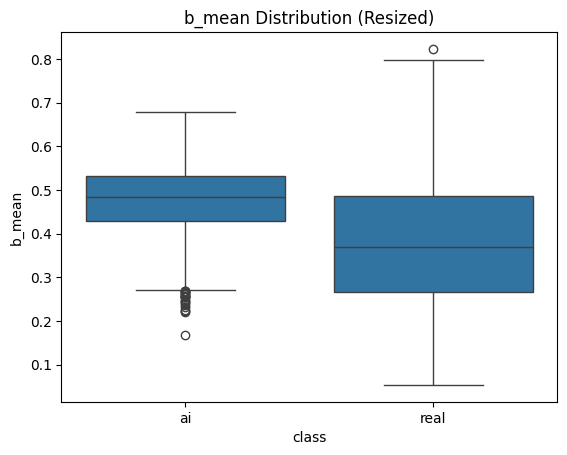

In [28]:
rgb_stats = []

for cls in ["ai", "real"]:
    for img_path in (TRAIN_RESIZED / cls).glob("*"):
        with Image.open(img_path) as img:
            img = np.array(img) / 255.0
            rgb_stats.append({
                "class": cls,
                "r_mean": img[:,:,0].mean(),
                "g_mean": img[:,:,1].mean(),
                "b_mean": img[:,:,2].mean()
            })

df_rgb_resized = pd.DataFrame(rgb_stats)

print("===== RGB CHANNEL STATS (RESIZED) =====")
print(df_rgb_resized.groupby("class").agg(["mean","std"]))

for channel in ["r_mean","g_mean","b_mean"]:
    sns.boxplot(data=df_rgb_resized, x="class", y=channel)
    plt.title(f"{channel} Distribution (Resized)")
    plt.show()

In [29]:
centered = []

for cls in ["ai", "real"]:
    for img_path in (TRAIN_RESIZED / cls).glob("*"):
        with Image.open(img_path) as img:
            img = np.array(img) / 255.0
            img = img - img.mean()   # centrar por imagen
            
            centered.append({
                "class": cls,
                "mean_after_center": img.mean()
            })

df_centered = pd.DataFrame(centered)

print(df_centered.groupby("class")["mean_after_center"].describe())

        count          mean           std           min           25%  \
class                                                                   
ai     3241.0  3.014892e-18  4.951185e-17 -2.125036e-16 -2.775558e-17   
real   3241.0 -1.800202e-18  4.139313e-17 -1.804112e-16 -2.775558e-17   

                50%           75%           max  
class                                            
ai     4.625929e-18  3.700743e-17  2.289835e-16  
real   0.000000e+00  2.312965e-17  1.665335e-16  


In [30]:


INTERIM_PATH = PROJECT_ROOT / "data" / "interim"
splits = ["train", "val", "test"]

def standardize_image(img_array):
    img_array = img_array / 255.0
    mean = img_array.mean()
    std = img_array.std()
    
    if std < 1e-6:
        return img_array
    
    img_array = (img_array - mean) / std
    return img_array

def rescale_for_saving(img_array):
    img_array = (img_array - img_array.min()) / (img_array.max() - img_array.min())
    img_array = (img_array * 255).astype(np.uint8)
    return img_array

for split in splits:
    
    source_path = INTERIM_PATH / f"{split}_balanced_resized"
    dest_path = INTERIM_PATH / f"{split}_balanced_standardized"
    
    for cls in ["ai", "real"]:
        (dest_path / cls).mkdir(parents=True, exist_ok=True)
        
        for img_path in (source_path / cls).glob("*"):
            
            with Image.open(img_path) as img:
                img = img.convert("RGB")
                img_array = np.array(img)
                
                standardized = standardize_image(img_array)
                img_to_save = rescale_for_saving(standardized)
                
                Image.fromarray(img_to_save).save(dest_path / cls / img_path.name)

print(" Standardization completada")

 Standardization completada


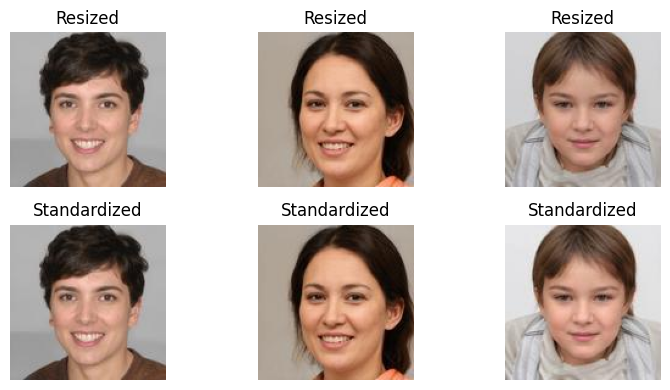

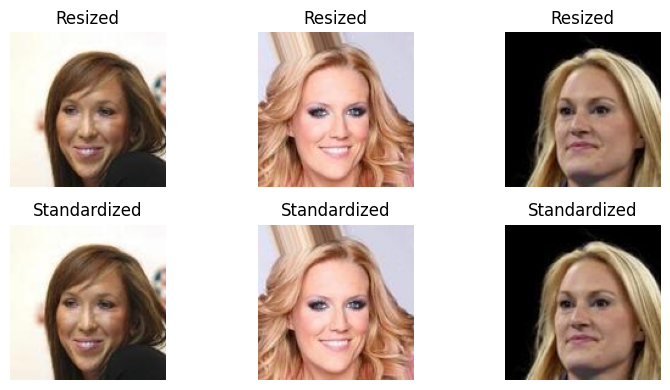

In [31]:


def show_brightness_comparison(split="train", cls="ai"):
    
    original_path = INTERIM_PATH / f"{split}_balanced_resized" / cls
    standardized_path = INTERIM_PATH / f"{split}_balanced_standardized" / cls
    
    samples = random.sample(list(original_path.glob("*")), 3)
    
    plt.figure(figsize=(8,4))
    
    for i, img_path in enumerate(samples):
        
        original_img = Image.open(img_path)
        standardized_img = Image.open(standardized_path / img_path.name)
        
        # Original
        plt.subplot(2,3,i+1)
        plt.imshow(original_img)
        plt.title("Resized")
        plt.axis("off")
        
        # Standardized
        plt.subplot(2,3,i+4)
        plt.imshow(standardized_img)
        plt.title("Standardized")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_brightness_comparison("train", "ai")
show_brightness_comparison("train", "real")

### Preprocessed

In [32]:
import numpy as np
from PIL import Image
from pathlib import Path

In [33]:
# ==========================================
# PREPROCESSED (TENSORES ANTES DE GUARDAR)
# ==========================================
# Objetivo:
# Convertir imágenes a tensores por batches (estilo notebook 1),
# y después guardar en data/processed como X.npy / y.npy.
#
# Ventajas:
# 1) DataLoader maneja batching eficientemente
# 2) El código es más escalable y reproducible
# 3) Mantiene una separación clara: lectura/transformación -> guardado

from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image

PROJECT_ROOT = Path().resolve().parent
INTERIM_PATH = PROJECT_ROOT / "data" / "interim"
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

# ----------------------------
# 1) Cargar manifest si existe
# ----------------------------
manifest_path = INTERIM_PATH / "manifest_interim.csv"
use_manifest = manifest_path.exists()

if use_manifest:
    df_manifest = pd.read_csv(manifest_path)
    print("Usando manifest:", manifest_path)
else:
    df_manifest = None
    print("No existe manifest_interim.csv, se usará glob directo.")

# ----------------------------
# 2) Transformaciones (Torch)
# ----------------------------
# Todas las imágenes deben salir con el mismo tamaño ANTES del batching.
# CenterCrop + Resize hacen que cualquier resolución (178x218, 256x256, etc.)
# termine en (TARGET_SIZE, TARGET_SIZE) de forma consistente.

TARGET_SIZE = 128

tensor_transform = transforms.Compose([
    transforms.CenterCrop(min(178, 218)),   # opcional; ver nota abajo
    transforms.Resize((TARGET_SIZE, TARGET_SIZE)),
    transforms.ToTensor(),                  # (C,H,W) float32 en [0,1]
])

# ----------------------------
# 3) Dataset personalizado
# ----------------------------
class ImagePathDataset(Dataset):
    """
    Dataset mínimo basado en una lista de rutas y etiquetas.
    Lee la imagen con PIL, la convierte a RGB y aplica transformaciones Torch.
    """
    def __init__(self, paths, labels, transform=None):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        y = self.labels[idx]

        with Image.open(path) as img:
            img = img.convert("RGB")
            x = self.transform(img) if self.transform else img

        # x: torch.Tensor (C,H,W), y: int
        return x, y

def build_split_paths_labels(split_name: str):
    """
    Devuelve (paths, labels) para un split.
    Prioriza manifest si existe; si no, usa glob sobre interim.
    """
    label_map = {"real": 0, "ai": 1}

    if use_manifest:
        df_split = df_manifest[df_manifest["split"] == split_name]
        paths = df_split["path"].tolist()
        labels = df_split["label"].astype(int).tolist()
        return paths, labels

    # fallback: glob
    paths = []
    labels = []
    for cls in ["real", "ai"]:
        folder = INTERIM_PATH / split_name / cls
        for p in folder.glob("*"):
            paths.append(str(p))
            labels.append(label_map[cls])

    return paths, labels

# ----------------------------
# 4) Conversión por batches
# ----------------------------
def dataloader_to_numpy(dataset, batch_size=128, num_workers=0, shuffle=False):
    """
    Itera DataLoader y concatena batches.
    Convierte CHW -> HWC al final para dejarlo en formato Keras/NumPy clásico.
    """
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=False
    )

    X_batches = []
    y_batches = []

    for X_t, y_t in loader:
        # X_t: (B,C,H,W) float32 en [0,1]
        # Pasamos a (B,H,W,C) para compatibilidad con tu pipeline actual
        X_t = X_t.permute(0, 2, 3, 1).contiguous()

        X_batches.append(X_t.numpy())
        y_batches.append(y_t.numpy())

    X = np.concatenate(X_batches, axis=0).astype(np.float32)
    y = np.concatenate(y_batches, axis=0).astype(np.int64)
    return X, y

# ----------------------------
# 5) Construcción y guardado final
# ----------------------------
splits = ["train", "val", "test"]

for split in splits:
    paths, labels = build_split_paths_labels(split)

    ds = ImagePathDataset(paths, labels, transform=tensor_transform)

    X, y = dataloader_to_numpy(
        ds,
        batch_size=128,
        num_workers=0,   # en Windows suele ser más estable dejarlo en 0
        shuffle=False
    )

    dest = PROCESSED_PATH / split
    dest.mkdir(parents=True, exist_ok=True)

    np.save(dest / "X.npy", X)
    np.save(dest / "y.npy", y)

    print(f"\n{split.upper()} guardado")
    print("Shape X:", X.shape, "| dtype:", X.dtype, "| range:", (X.min(), X.max()))
    print("Shape y:", y.shape, "| dtype:", y.dtype)

Usando manifest: C:\Users\maria\Desktop\DL\autoencoder-project\data\interim\manifest_interim.csv

TRAIN guardado
Shape X: (41741, 128, 128, 3) | dtype: float32 | range: (np.float32(0.0), np.float32(1.0))
Shape y: (41741,) | dtype: int64

VAL guardado
Shape X: (8944, 128, 128, 3) | dtype: float32 | range: (np.float32(0.0), np.float32(1.0))
Shape y: (8944,) | dtype: int64

TEST guardado
Shape X: (8945, 128, 128, 3) | dtype: float32 | range: (np.float32(0.0), np.float32(1.0))
Shape y: (8945,) | dtype: int64


### EDA

In [34]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [35]:
PROJECT_ROOT = Path().resolve().parent

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"

X_train = np.load(PROCESSED_PATH / "train" / "X.npy")
y_train = np.load(PROCESSED_PATH / "train" / "y.npy")

print("Shape X:", X_train.shape)
print("Shape y:", y_train.shape)
print("Pixel range:", X_train.min(), "to", X_train.max())

Shape X: (41741, 128, 128, 3)
Shape y: (41741,)
Pixel range: 0.0 to 1.0


===== CLASS DISTRIBUTION (PROCESSED) =====
  class  count  percentage
0  real  38500   92.235452
1    ai   3241    7.764548


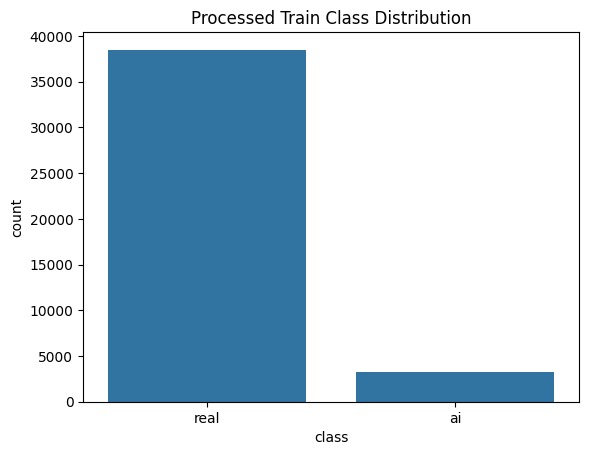

In [36]:
unique, counts = np.unique(y_train, return_counts=True)

df_balance = pd.DataFrame({
    "class": ["real", "ai"],
    "count": counts
})

df_balance["percentage"] = df_balance["count"] / df_balance["count"].sum() * 100

print("===== CLASS DISTRIBUTION (PROCESSED) =====")
print(df_balance)

sns.barplot(data=df_balance, x="class", y="count")
plt.title("Processed Train Class Distribution")
plt.show()

In [37]:
heights = X_train.shape[1]
widths = X_train.shape[2]

print("===== RESOLUTION CHECK =====")
print("Height:", heights)
print("Width:", widths)

===== RESOLUTION CHECK =====
Height: 128
Width: 128


In [38]:
brightness_ai = X_train[y_train == 1].mean(axis=(1,2,3))
brightness_real = X_train[y_train == 0].mean(axis=(1,2,3))

print("===== BRIGHTNESS STATS (PROCESSED) =====")
print("AI mean:", brightness_ai.mean())
print("Real mean:", brightness_real.mean())
print("Absolute difference:", abs(brightness_ai.mean() - brightness_real.mean()))

===== BRIGHTNESS STATS (PROCESSED) =====
AI mean: 0.50100076
Real mean: 0.43531635
Absolute difference: 0.06568441


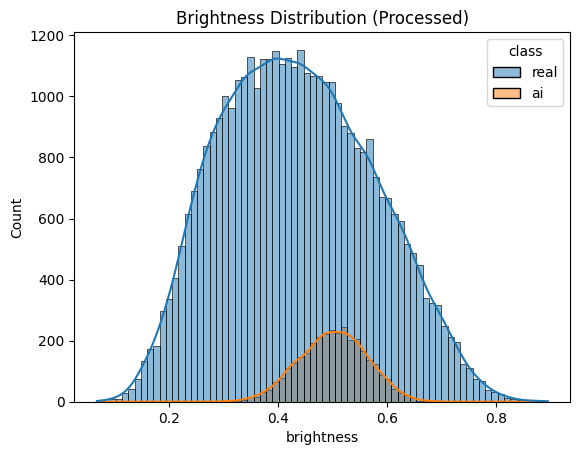

In [39]:
df_brightness = pd.DataFrame({
    "brightness": np.concatenate([brightness_real, brightness_ai]),
    "class": ["real"] * len(brightness_real) + ["ai"] * len(brightness_ai)
})

sns.histplot(data=df_brightness, x="brightness", hue="class", kde=True)
plt.title("Brightness Distribution (Processed)")
plt.show()

In [40]:
rgb_ai = X_train[y_train == 1]
rgb_real = X_train[y_train == 0]

print("===== RGB MEAN COMPARISON =====")
print("AI mean RGB:", rgb_ai.mean(axis=(0,1,2)))
print("Real mean RGB:", rgb_real.mean(axis=(0,1,2)))

===== RGB MEAN COMPARISON =====
AI mean RGB: [0.31595185 0.31595185 0.31595185]
Real mean RGB: [0.0265974 0.0265974 0.0265974]


REAL samples:


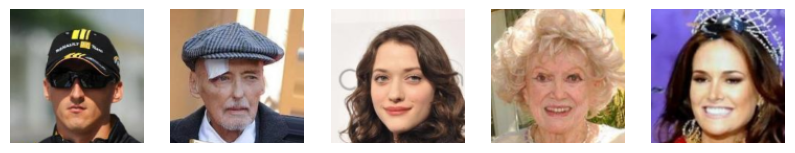

AI samples:


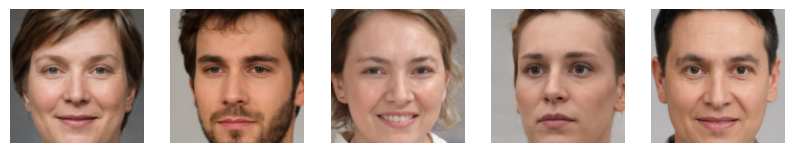

In [41]:


def show_samples(class_label):
    idxs = np.where(y_train == class_label)[0]
    samples = random.sample(list(idxs), 5)
    
    plt.figure(figsize=(10,2))
    for i, idx in enumerate(samples):
        plt.subplot(1,5,i+1)
        plt.imshow(X_train[idx])
        plt.axis("off")
    plt.show()

print("REAL samples:")
show_samples(0)

print("AI samples:")
show_samples(1)